##Import

In [ ]:
# Kết nối Google Colab vào Google Drive
from google.colab import drive
drive.mount("/content/drive")
# Chuyển đến thư mục làm việc
%cd /content/drive/MyDrive/Kyanon

Mounted at /content/drive
/content/drive/MyDrive/Kyanon


In [ ]:
# !ls -a

In [ ]:
# !tar -xvf /content/drive/MyDrive/Kyanon/PP-OCRv5_server_det_infer.tar -C /content/drive/MyDrive/Kyanon/

In [ ]:
# !tar -xvf /content/drive/MyDrive/Kyanon/PP-OCRv5_server_rec_infer.tar -C /content/drive/MyDrive/Kyanon/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install paddlepaddle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


## Step 1: Detect

In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/Kyanon/image-test/IMG_8429 Large.jpeg"
DICT_PATH = "/content/drive/MyDrive/Kyanon/Dataset_Invoice/inference_model/en_dict.txt"
DET_DIR = "/content/drive/MyDrive/Kyanon/PP-OCRv5_server_det_infer"
REC_DIR = "/content/drive/MyDrive/Kyanon/Dataset_Invoice/inference_model"

In [ ]:
import os
import cv2
import numpy as np
import paddle
import matplotlib.pyplot as plt
import math
from paddle.inference import Config, create_predictor

📂 Model file: inference.json
📂 Params file: inference.pdiparams
🐢 Running on CPU
✅ Load Predictor thành công!
🔄 Đang xử lý ảnh: IMG_8429 Large.jpeg
✅ Tìm thấy 43 text blocks.


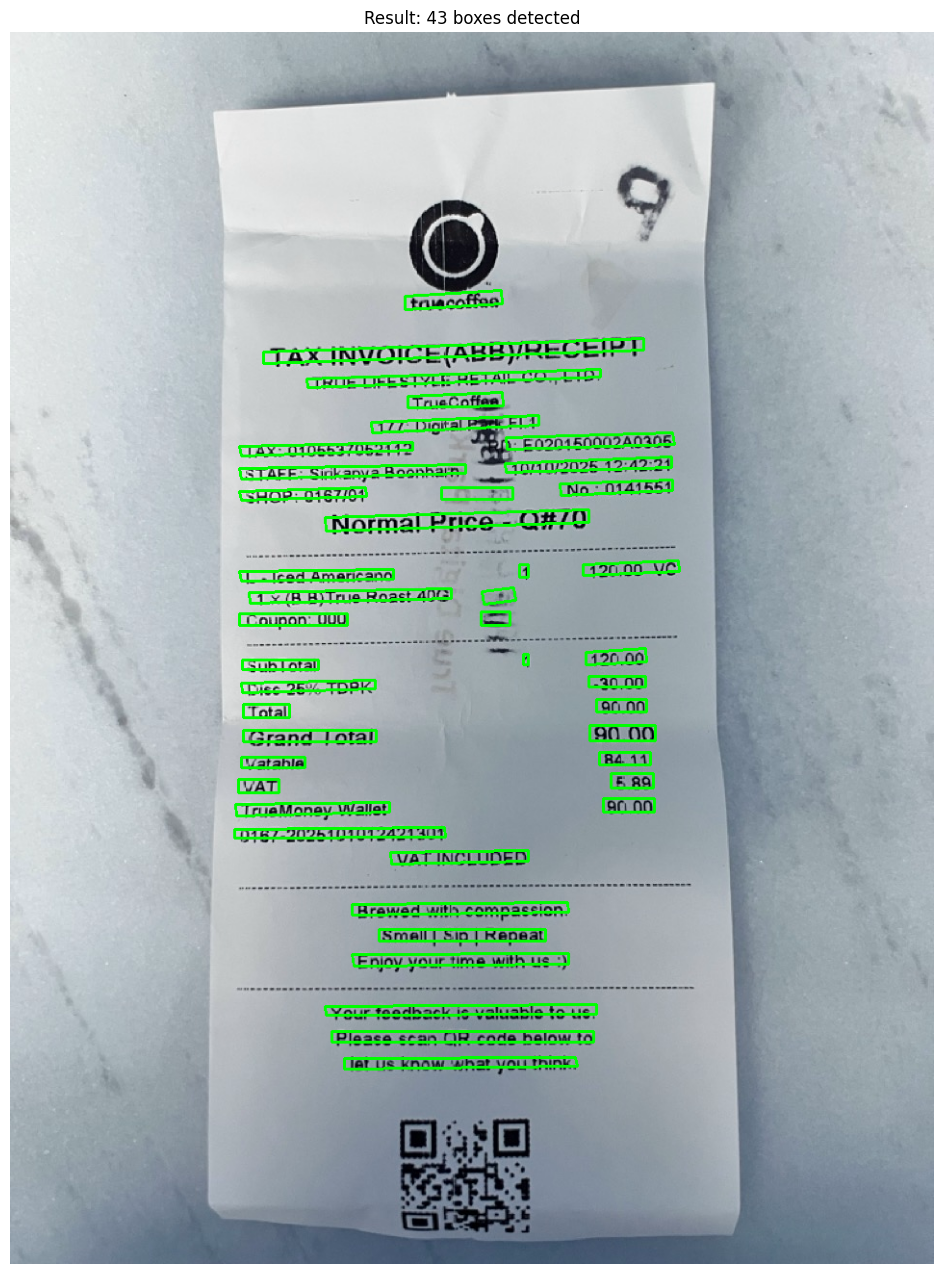

In [ ]:


# =====================================================
# 1. CLASS CẤU HÌNH (DBNet Configuration)
# =====================================================
class DBConfig:
    def __init__(self):
        self.thresh = 0.3          # Ngưỡng pixel: > 0.3 được coi là text
        self.box_thresh = 0.5      # Ngưỡng tin cậy của box
        self.max_candidates = 1000 # Số lượng box tối đa
        self.unclip_ratio = 1.6    # Tỉ lệ mở rộng vùng text
        self.min_size = 3          # Loại bỏ box quá nhỏ

# =====================================================
# 2. CÁC HÀM XỬ LÝ HÌNH HỌC (Unclip & Polygon)
# =====================================================
def py_clipper_expand(box, distance):
    box = np.array(box, dtype=np.float32)
    center = np.mean(box, axis=0)
    vectors = box - center
    lengths = np.linalg.norm(vectors, axis=1, keepdims=True)
    lengths[lengths == 0] = 1
    unit_vectors = vectors / lengths
    expanded_box = box + unit_vectors * distance
    return expanded_box.astype(np.int32)

def unclip(box, unclip_ratio=1.6): #Để tăng kích thước vùng bao bọc (bbox) rộng hơn, bạn cần điều chỉnh tham số unclip_ratio trong class DBConfig
    poly = cv2.convexHull(box)
    area = cv2.contourArea(poly)
    length = cv2.arcLength(poly, True)
    if length <= 0: return None
    distance = area * unclip_ratio / length
    return py_clipper_expand(box, distance)

def box_score_fast(bitmap, _box):
    h, w = bitmap.shape[:2]
    box = _box.copy()
    xmin = np.clip(np.floor(box[:, 0].min()).astype(np.int32), 0, w - 1)
    xmax = np.clip(np.ceil(box[:, 0].max()).astype(np.int32), 0, w - 1)
    ymin = np.clip(np.floor(box[:, 1].min()).astype(np.int32), 0, h - 1)
    ymax = np.clip(np.ceil(box[:, 1].max()).astype(np.int32), 0, h - 1)

    mask = np.zeros((ymax - ymin + 1, xmax - xmin + 1), dtype=np.uint8)
    box[:, 0] = box[:, 0] - xmin
    box[:, 1] = box[:, 1] - ymin
    cv2.fillPoly(mask, box.reshape(1, -1, 2).astype(np.int32), 1)
    return cv2.mean(bitmap[ymin:ymax + 1, xmin:xmax + 1], mask)[0]

def boxes_from_bitmap(pred, bitmap, dest_width, dest_height, config):
    contours, _ = cv2.findContours((bitmap * 255).astype(np.uint8), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    boxes, scores = [], []

    for contour in contours[:config.max_candidates]:
        epsilon = 0.002 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        points = approx.reshape((-1, 2))

        if len(points) < 4: continue
        score = box_score_fast(pred, points)
        if score < config.box_thresh: continue

        box = cv2.minAreaRect(points)
        box_points = cv2.boxPoints(box)
        if min(box[1]) < config.min_size: continue

        expanded_box = unclip(box_points, config.unclip_ratio)
        if expanded_box is None: continue

        rect = cv2.minAreaRect(expanded_box)
        final_box = cv2.boxPoints(rect)

        final_box[:, 0] = np.clip(final_box[:, 0], 0, dest_width)
        final_box[:, 1] = np.clip(final_box[:, 1], 0, dest_height)

        boxes.append(final_box.astype(np.int32))
        scores.append(score)

    return boxes, scores

# =====================================================
# 3. HÀM LOAD MODEL (UPDATED: DÙNG PREDICTOR)
# =====================================================
def load_db_predictor(model_dir):
    """
    Load model sử dụng Paddle Inference (hỗ trợ cả .json và .pdmodel)
    """
    try:
        # 1. Tìm file params (Bắt buộc phải có)
        params_file = os.path.join(model_dir, "inference.pdiparams")
        if not os.path.exists(params_file):
             print(f"❌ Không tìm thấy file params: {params_file}")
             return None

        # 2. Tìm file model (Ưu tiên .pdmodel, nếu không có thì tìm .json)
        model_file = os.path.join(model_dir, "inference.pdmodel")
        if not os.path.exists(model_file):
            model_file = os.path.join(model_dir, "inference.json") # Fallback sang json

        if not os.path.exists(model_file):
            print(f"❌ Không tìm thấy file model (.pdmodel hoặc .json) tại: {model_dir}")
            return None

        print(f"📂 Model file: {os.path.basename(model_file)}")
        print(f"📂 Params file: {os.path.basename(params_file)}")

        # 3. Tạo Config cho Predictor
        config = Config(model_file, params_file)

        # Cấu hình phần cứng (Tự động dùng GPU nếu có, không thì CPU)
        if paddle.device.is_compiled_with_cuda():
            config.enable_use_gpu(100, 0)
            print("⚡ Running on GPU")
        else:
            config.disable_gpu()
            config.set_cpu_math_library_num_threads(4) # Dùng 4 luồng CPU
            print("🐢 Running on CPU")

        # Tắt log tối ưu (đỡ rác màn hình)
        config.switch_use_feed_fetch_ops(False)
        config.switch_ir_optim(True)

        # 4. Tạo Predictor
        predictor = create_predictor(config)
        print("✅ Load Predictor thành công!")
        return predictor

    except Exception as e:
        print(f"❌ Lỗi khi khởi tạo Predictor: {e}")
        return None

def preprocess_image(image_path, limit_side=960):
    img = cv2.imread(image_path)
    if img is None: return None, None, None

# [FIX 1] Chuyển BGR -> RGB (PaddleOCR bắt buộc)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Resize giữ aspect ratio
    ratio = 1.0
    if max(h, w) > limit_side:
        if h > w:
            ratio = limit_side / h
        else:
            ratio = limit_side / w

    resize_h = int(h * ratio)
    resize_w = int(w * ratio)

    # Padding về bội số 32
    resize_h = max(int(round(resize_h / 32) * 32), 32)
    resize_w = max(int(round(resize_w / 32) * 32), 32)

    img_resized = cv2.resize(img, (resize_w, resize_h))

    # Normalize
    img_mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3).astype('float32')
    img_std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3).astype('float32')

    img_normalized = (img_resized.astype('float32') / 255.0 - img_mean) / img_std

    # CHW format & Batch dim
    img_tensor = img_normalized.transpose((2, 0, 1))
    img_tensor = np.expand_dims(img_tensor, 0)

    return img, img_tensor, (ratio, rh := resize_h, rw := resize_w) # Python 3.8+ walrus

# =====================================================
# 4. HÀM MAIN PROCESS (UPDATED: DÙNG PREDICTOR)
# =====================================================
def run_invoice_detection(predictor, image_path):
    print(f"🔄 Đang xử lý ảnh: {os.path.basename(image_path)}")

    # 1. Preprocess
    original_img, img_tensor, (ratio, rh, rw) = preprocess_image(image_path, limit_side=960)
    if original_img is None:
        print("❌ Lỗi đọc ảnh.")
        return

    # 2. Inference bằng Predictor (Khác với model thường)
    input_names = predictor.get_input_names()
    input_tensor = predictor.get_input_handle(input_names[0])

    # Copy dữ liệu từ CPU vào bộ nhớ model
    input_tensor.copy_from_cpu(img_tensor)

    # Chạy model
    predictor.run()

    # Lấy output
    output_names = predictor.get_output_names()
    output_tensor = predictor.get_output_handle(output_names[0])
    output_data = output_tensor.copy_to_cpu() # Numpy array

    # Output shape: (Batch, Channel, H, W) -> Lấy (H, W)
    pred = output_data[0, 0, :, :]

    # 3. Post-Processing
    config = DBConfig()
    segmentation = pred > config.thresh

    boxes, scores = boxes_from_bitmap(pred, segmentation, rw, rh, config)

    # Rescale về ảnh gốc
    final_boxes = []
    scale_x = original_img.shape[1] / rw
    scale_y = original_img.shape[0] / rh

    for i, box in enumerate(boxes):
        box = box.astype(np.float32)
        box[:, 0] *= scale_x
        box[:, 1] *= scale_y
        final_boxes.append(box.astype(np.int32))


    print(f"✅ Tìm thấy {len(final_boxes)} text blocks.")



    # 4. Visualization
    vis_img = original_img.copy()
    for box in final_boxes:
        cv2.polylines(vis_img, [box], True, (0, 255, 0), 2)

    plt.figure(figsize=(12, 16))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Result: {len(final_boxes)} boxes detected")
    plt.show()
    return final_boxes

# =====================================================
# 5. CHẠY THỬ
# =====================================================

# 1. Cài đặt đường dẫn (Check kỹ đường dẫn của bạn)


# 2. Load Predictor
predictor = load_db_predictor(DET_DIR)

# 3. Run Inference
if predictor:
    if os.path.exists(IMAGE_PATH):
        run_invoice_detection(predictor, IMAGE_PATH)
    else:
        print(f"⚠️ Không tìm thấy ảnh tại: {IMAGE_PATH}")

## Step 2: REC

In [ ]:
# ===== LOAD MODEL RECOGNITION =====

def load_recognition_model(model_dir):
    """Load model recognition"""
    try:


        model_file = f"{model_dir}/inference.json"
        params_file = f"{model_dir}/inference.pdiparams"

        if os.path.exists(model_file) and os.path.exists(params_file):
            print(f"✅ [RECOGNITION] Tìm thấy model files:")
            print(f"   - {model_file}")
            print(f"   - {params_file}")

            model = paddle.jit.load(model_dir + "/inference")
            print("✅ [RECOGNITION] Load model thành công!")
            return model
        else:
            print("❌ [RECOGNITION] Không tìm thấy file model")
            return None
    except Exception as e:
        print(f"❌ [RECOGNITION] Lỗi: {e}")
        return None

# Load model
print("🔄 LOADING RECOGNITION MODEL...")
print("="*60)
rec_model = load_recognition_model(REC_DIR)  # Thay đường dẫn của bạn
print("="*60)

🔄 LOADING RECOGNITION MODEL...
✅ [RECOGNITION] Tìm thấy model files:
   - /content/drive/MyDrive/Kyanon/Dataset_Invoice/inference_model/inference.json
   - /content/drive/MyDrive/Kyanon/Dataset_Invoice/inference_model/inference.pdiparams
✅ [RECOGNITION] Load model thành công!



🚀 BƯỚC 1: CHẠY DETECTION
🔄 Đang xử lý ảnh: IMG_8429 Large.jpeg
✅ Tìm thấy 43 text blocks.


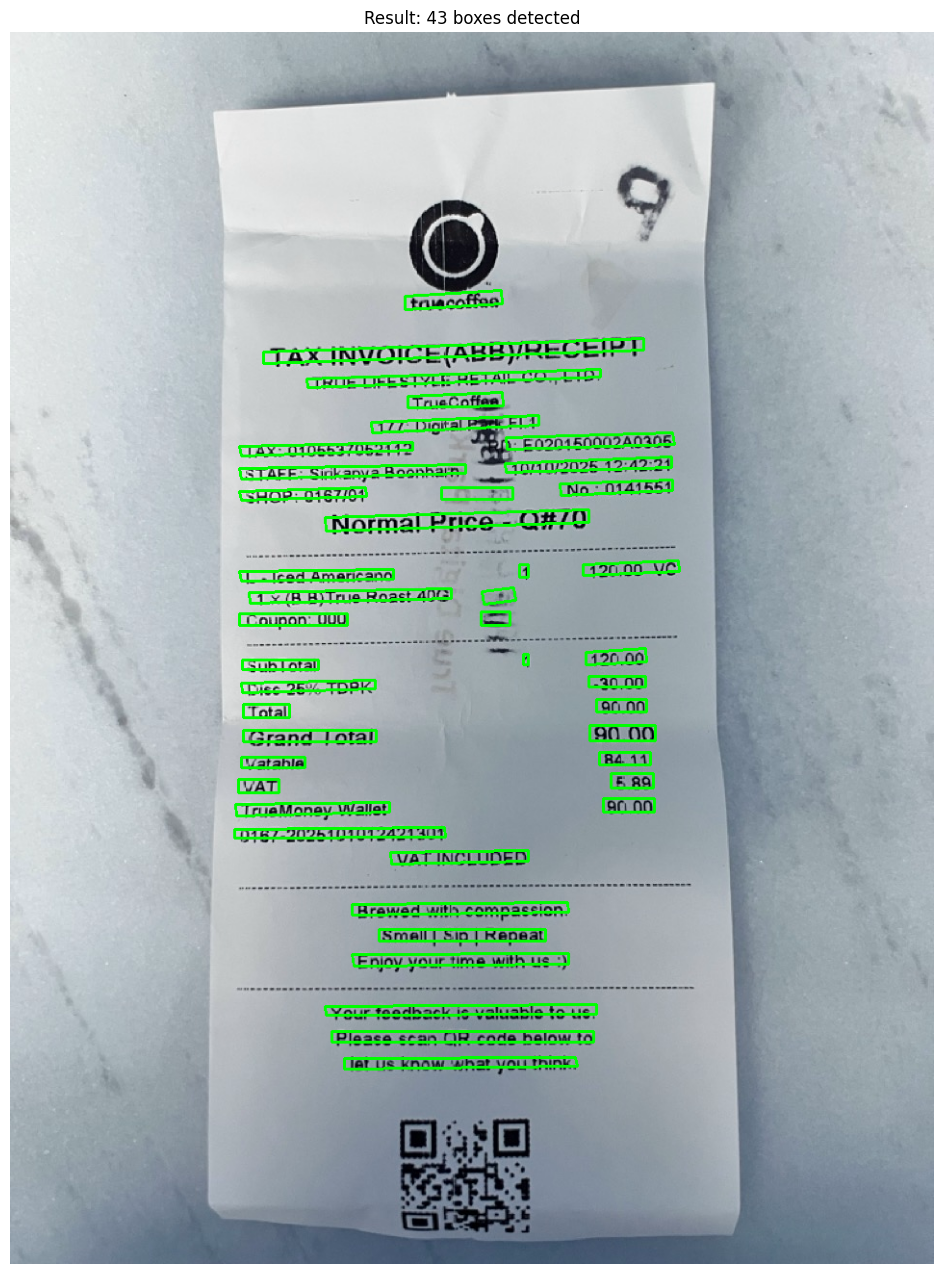


🚀 BƯỚC 2: RECOGNITION
🔄 Bắt đầu nhận diện 43 vùng text...
✅ Đã load dict: 67 ký tự.
  ✅ 'truecoffee' (conf: 0.95)
✅ Đã load dict: 67 ký tự.
  ✅ 'TAXINVOICEABBRECEIPT' (conf: 0.99)
✅ Đã load dict: 67 ký tự.
  ✅ 'TRUELFESTYLERETAILCO,LTD.' (conf: 0.91)
✅ Đã load dict: 67 ký tự.
  ✅ 'TrueCoffee' (conf: 0.96)
✅ Đã load dict: 67 ký tự.
  ✅ '177DigtalPamkFl.1' (conf: 0.90)
✅ Đã load dict: 67 ký tự.
  ✅ 'TAX0105537052112' (conf: 1.00)
✅ Đã load dict: 67 ký tự.
  ✅ 'OE020150002A0305' (conf: 0.93)
✅ Đã load dict: 67 ký tự.
  ✅ 'STAFFSinikanyaBoonhain' (conf: 0.92)
✅ Đã load dict: 67 ký tự.
  ✅ '10102025124221' (conf: 0.99)
✅ Đã load dict: 67 ký tự.
  ✅ 'T1' (conf: 0.50)
✅ Đã load dict: 67 ký tự.
  ✅ 'SHOP016701' (conf: 0.95)
✅ Đã load dict: 67 ký tự.
  ✅ 'No.0141551' (conf: 0.99)
✅ Đã load dict: 67 ký tự.
  ✅ 'NormalPrice-Q70' (conf: 0.98)
✅ Đã load dict: 67 ký tự.
✅ Đã load dict: 67 ký tự.
  ✅ 'L-IcedAmericano' (conf: 0.97)
✅ Đã load dict: 67 ký tự.
  ✅ '120.00VC' (conf: 0.94)
✅ Đã load dict:

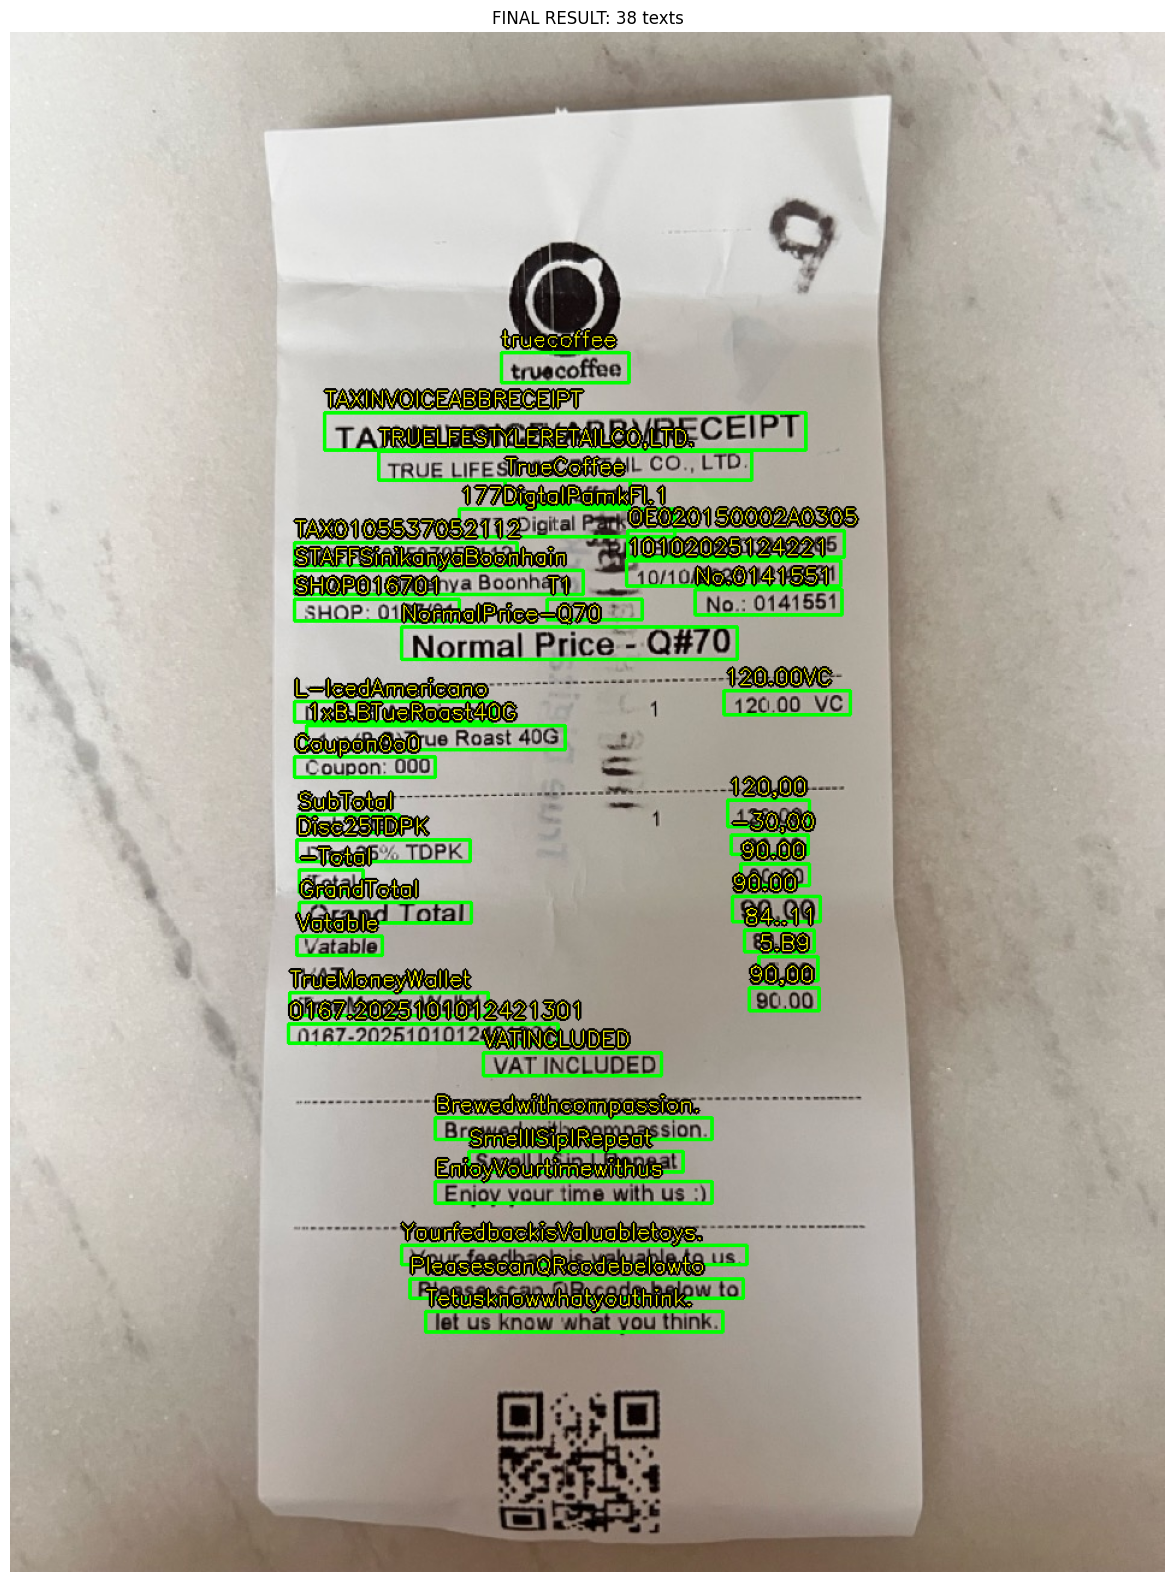

In [ ]:
import cv2
import numpy as np
import paddle
import matplotlib.pyplot as plt

# =====================================================
# 1. HÀM CHUYỂN ĐỔI POLYGON -> RECTANGLE
# =====================================================
def get_mini_boxes(contour):
    """
    Chuyển đổi polygon 4 điểm thành bounding box chữ nhật (x, y, w, h)
    để crop ảnh dễ dàng hơn cho model recognition.
    """
    bounding_box = cv2.boundingRect(contour)
    return bounding_box

def sorted_boxes(dt_boxes):
    """
    Sắp xếp các box từ trên xuống dưới, từ trái qua phải
    để thứ tự text sau khi đọc được tự nhiên.
    """
    num_boxes = len(dt_boxes)
    sorted_boxes = sorted(dt_boxes, key=lambda x: (x[0][1], x[0][0]))
    _boxes = list(sorted_boxes)

    for i in range(num_boxes - 1):
        if abs(_boxes[i + 1][0][1] - _boxes[i][0][1]) < 10 and \
                (_boxes[i + 1][0][0] < _boxes[i][0][0]):
            tmp = _boxes[i]
            _boxes[i] = _boxes[i + 1]
            _boxes[i + 1] = tmp
    return _boxes

# =====================================================
# 2. HÀM RECOGNITION ĐÃ FIX (QUAN TRỌNG)
# =====================================================
def recognize_text(rec_model, image, polygons):
    """
    Chạy nhận diện text trên danh sách polygons từ detection
    """
    results = []
    h_img, w_img = image.shape[:2]

    # Sắp xếp box để đọc đúng thứ tự dòng
    sorted_polys = sorted_boxes(polygons)

    print(f"🔄 Bắt đầu nhận diện {len(sorted_polys)} vùng text...")

    for i, poly in enumerate(sorted_polys):
        # 1. Cắt ảnh (Crop) chuẩn xác từ Polygon
        # Dùng boundingRect để lấy vùng chữ nhật bao quanh polygon
        x, y, w, h = cv2.boundingRect(poly)

        # Mở rộng vùng crop một chút (padding) để không bị mất nét chữ ở rìa
        pad = 2
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(w_img - x, w + 2*pad)
        h = min(h_img - y, h + 2*pad)

        cropped_img = image[y:y+h, x:x+w]

        # Kiểm tra ảnh crop hợp lệ
        if cropped_img.size == 0 or w < 5 or h < 5:
            continue

        # 2. Tiền xử lý cho Recognition Model (Resize về 320x48)
        # Lưu ý: Model Recog cần ảnh input shape [1, 3, 48, 320] hoặc [1, 3, 32, 100] tùy config
        # Ở đây ta dùng chuẩn phổ biến của PaddleOCR v3/v4 server là cao 48
        rec_h = 48
        rec_w = 320
        resized_img = cv2.resize(cropped_img, (rec_w, rec_h))

        # Normalize & Transpose
        norm_img = resized_img.astype(np.float32) / 255.0
        norm_img = (norm_img - 0.5) / 0.5 # Chuẩn hóa mean=0.5, std=0.5 (Paddle default)
        norm_img = norm_img.transpose((2, 0, 1)) # HWC -> CHW
        input_tensor = np.expand_dims(norm_img, axis=0) # Add Batch Dim -> [1, 3, 48, 320]

        # 3. Inference
        try:
            # Chuyển dữ liệu sang Tensor
            x_tensor = paddle.to_tensor(input_tensor)

            # Chạy model
            with paddle.no_grad():
                output = rec_model(x_tensor)

            # 4. Decode kết quả (CTC Decode)
            # Lưu ý: Output model thường là softmax logits -> cần argmax -> tra từ điển
            text, conf = decode_output(output)

            if conf > 0.5: # Chỉ lấy kết quả tin cậy > 50%
                results.append({
                    'poly': poly,
                    'text': text,
                    'conf': conf,
                    'rect': (x, y, w, h) # Lưu lại để vẽ
                })
                print(f"  ✅ '{text}' (conf: {conf:.2f})")

        except Exception as e:
            print(f"  ❌ Lỗi tại box {i}: {e}")
            continue

    return results

# =====================================================
# 3. HÀM DECODE (CTCLoss -> Text)
# =====================================================
# Bạn cần file dict tương ứng với model. Nếu dùng English mặc định:


def get_char_dict(path=DICT_PATH):
    """
    Load character dictionary từ file txt.
    """
    # 1. Kiểm tra file
    if not os.path.exists(path):
        print(f"⚠️ CẢNH BÁO: Không tìm thấy file dict tại '{path}'")
        print("👉 Dùng dict mặc định (En)...")
        default_chars = "0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~ "
        return ['blank'] + list(default_chars)

    # 2. Đọc file
    try:
        chars = []
        with open(path, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        for line in lines:
            # Strip ký tự xuống dòng nhưng giữ lại khoảng trắng
            char = line.strip('\n').strip('\r')
            chars.append(char)

        if ' ' not in chars: chars.append(' ') # Đảm bảo có dấu cách

        print(f"✅ Đã load dict: {len(chars)} ký tự.")
        return ['blank'] + chars

    except Exception as e:
        print(f"❌ Lỗi đọc file dict: {e}")
        return ['blank']

def decode_output(output_tensor):
    """Giải mã output của mạng nơ-ron thành chữ"""
    # Lấy argmax để tìm chỉ số có xác suất cao nhất
    preds_idx = paddle.argmax(output_tensor, axis=2) # [Batch, Time_step]
    preds_prob = paddle.max(output_tensor, axis=2)

    preds_idx = preds_idx.numpy()[0]
    preds_prob = preds_prob.numpy()[0]

    char_list = get_char_dict()
    text = ""
    conf_list = []

    last_index = 0
    for i, index in enumerate(preds_idx):
        # CTC logic: bỏ qua ký tự trùng lặp liên tiếp và ký tự blank (index 0)
        if index != last_index and index != 0 and index < len(char_list):
            text += char_list[index]
            conf_list.append(preds_prob[i])
        last_index = index

    avg_conf = sum(conf_list) / len(conf_list) if conf_list else 0.0
    return text, avg_conf

# =====================================================
# 4. MAIN PIPELINE (CHẠY CÁI NÀY)
# =====================================================
def run_full_system(img_path, det_model, rec_model):
    # --- BƯỚC 0: ĐỌC ẢNH GỐC (Fix lỗi NameError tại đây) ---
    original_img = cv2.imread(img_path)
    if original_img is None:
        print(f"❌ Không tìm thấy ảnh: {img_path}")
        return

    # --- BƯỚC 1: DETECTION ---
    print("\n🚀 BƯỚC 1: CHẠY DETECTION")

    # Gọi hàm detection từ các cell trước
    if 'run_invoice_detection' in globals():
        # Hàm này trả về list các boxes
        final_boxes = run_invoice_detection(det_model, img_path)
    else:
        print("❌ LỖI: Chưa chạy cell chứa hàm 'run_invoice_detection'.")
        return

    if final_boxes is None or len(final_boxes) == 0:
        print("⚠️ Không tìm thấy box nào.")
        return

    # --- BƯỚC 2: RECOGNITION ---
    print("\n🚀 BƯỚC 2: RECOGNITION")

    # Biến original_img giờ đã được định nghĩa ở Bước 0
    ocr_results = recognize_text(rec_model, original_img, final_boxes)

    # --- BƯỚC 3: HIỂN THỊ KẾT QUẢ ---
    vis_img = original_img.copy()
    for item in ocr_results:
        rect = item['rect']
        text = item['text']

        # Vẽ Box
        cv2.rectangle(vis_img, (rect[0], rect[1]), (rect[0]+rect[2], rect[1]+rect[3]), (0, 255, 0), 2)
        # Vẽ Text (Viền đen + Chữ vàng)
        cv2.putText(vis_img, text, (rect[0], rect[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
        cv2.putText(vis_img, text, (rect[0], rect[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 1)

    plt.figure(figsize=(15, 20))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"FINAL RESULT: {len(ocr_results)} texts")
    plt.show()

    # Trả về kết quả để dùng cho bước Extract Total
    return ocr_results

# =====================================================
# CHẠY TEST
# =====================================================
if 'predictor' in locals() and 'rec_model' in locals():
    # Lưu kết quả vào biến 'results' để dùng cho cell Extract Total sau này
    results = run_full_system(IMAGE_PATH, predictor, rec_model)
else:
    print("⚠️ Thiếu model! Hãy đảm bảo đã load Detection và Recognition model.")

In [ ]:
import re

# =====================================================
# 1. CÁC HÀM HỖ TRỢ TÍNH TOÁN
# =====================================================
def calculate_y_overlap(box1, box2):
    """
    Tính tỷ lệ chồng lấn theo chiều dọc (Y-axis).
    Input: box [x1, y1, x2, y2]
    """
    # box structure: [x1, y1, x2, y2]
    y1_a, y2_a = box1[1], box1[3]
    y1_b, y2_b = box2[1], box2[3]

    intersect_start = max(y1_a, y1_b)
    intersect_end = min(y2_a, y2_b)

    if intersect_end <= intersect_start: return 0.0

    overlap_height = intersect_end - intersect_start
    min_height = min(y2_a - y1_a, y2_b - y1_b)

    if min_height == 0: return 0.0
    return overlap_height / min_height

def clean_money_string(text):
    """Làm sạch chuỗi tiền"""
    if not text: return ""
    cleaned = re.sub(r'[^\d.,]', '', text)
    cleaned = cleaned.rstrip('.,')
    return cleaned

# =====================================================
# 2. HÀM TRÍCH XUẤT TOTAL (ĐÃ SỬA DATA MAPPING)
# =====================================================
def extract_grand_total_v3(ocr_results):
    print("\n🔍 BẮT ĐẦU TRÍCH XUẤT TOTAL...")

    # --- BƯỚC 0: CHUẨN HÓA DỮ LIỆU (QUAN TRỌNG NHẤT) ---
    # Mục tiêu: Chuyển đổi output từ Pipeline về dạng chuẩn:
    # {'text': str, 'bbox': [x1, y1, x2, y2], 'conf': float}

    standardized_data = []

    for item in ocr_results:
        text = str(item.get('text', '')).lower()
        raw_text = str(item.get('text', ''))
        conf = item.get('conf', 0.0)

        # Xử lý tọa độ: Pipeline trả về 'rect': (x, y, w, h)
        if 'rect' in item:
            x, y, w, h = item['rect']
            # Convert sang [x1, y1, x2, y2] để tính toán
            bbox_xyxy = [x, y, x + w, y + h]

        elif 'bbox' in item:
            # Fallback nếu dùng code cũ
            box = item['bbox']
            if len(box) == 4:
                bbox_xyxy = box # Giả định đã là xyxy
            else:
                continue # Bỏ qua nếu format lạ
        else:
            continue # Không có thông tin vị trí -> Bỏ qua

        standardized_data.append({
            'text': text,          # Text thường để so sánh từ khóa
            'text_raw': raw_text,  # Text gốc để hiển thị/trích xuất
            'bbox': bbox_xyxy,     # [x1, y1, x2, y2]
            'conf': conf
        })

    # --- BƯỚC 1: TỪ KHÓA ---
    priority_keywords = ['grand total', 'amount due', 'total due', 'amount to pay', 'thanh toan', 'tong tien', 'cong tien', 'phai thu']
    generic_keywords = ['total', 'tổng', 'cộng']
    exclude_keywords = ['sub', 'net', 'tax', 'vat', 'trước thuế', 'discount', 'khuyến mãi', 'qty', 'sl']

    candidates = []

    for item in standardized_data:
        text = item['text']
        bbox = item['bbox']

        if any(ex in text for ex in exclude_keywords): continue

        score = 0
        if any(pk in text for pk in priority_keywords): score = 2
        elif any(gk in text for gk in generic_keywords): score = 1

        if score > 0:
            # Lưu candidate kèm độ ưu tiên và vị trí Y (đáy box - y2)
            candidates.append({'item': item, 'score': score, 'bottom_y': bbox[3]})

    # --- BƯỚC 2: CHỌN NHÃN & TÌM GIÁ TRỊ ---
    if candidates:
        # Sort: Score cao nhất -> Nằm dưới cùng (Y lớn nhất)
        candidates.sort(key=lambda x: (x['score'], x['bottom_y']), reverse=True)
        top_labels = candidates[:3]

        print(f"   👉 Tìm thấy {len(candidates)} từ khóa Total. Đang kiểm tra...")

        for cand in top_labels:
            label_item = cand['item']
            label_bbox = label_item['bbox']
            print(f"   ❓ Kiểm tra nhãn: '{label_item['text_raw']}'")

            # Check 1: Số nằm ngay trong dòng (Inline) VD: "Total: 500.000"
            inline_nums = re.findall(r'[\d.,]+', label_item['text_raw'])
            # Số hợp lệ phải có ít nhất 3 chữ số (tránh số trang "1/2")
            valid_inline = [n for n in inline_nums if len(re.sub(r'[^\d]', '', n)) >= 3]
            if valid_inline:
                return clean_money_string(valid_inline[-1])

            # Check 2: Quét các box khác để tìm giá trị bên phải
            possible_values = []
            for item in standardized_data:
                if item == label_item: continue

                val_text = item['text_raw']
                val_bbox = item['bbox']

                # Phải chứa số và độ dài số >= 2
                if not re.search(r'\d', val_text): continue
                if len(re.sub(r'[^\d]', '', val_text)) < 2: continue

                # Logic vị trí:
                # 1. Nằm bên phải nhãn (x1_val > x1_label + nửa chiều rộng nhãn)
                # Cho phép lùi lại một chút (x1_label) để bắt các trường hợp dính sát
                if val_bbox[0] < label_bbox[0]: continue

                # 2. Overlap chiều cao > 30% (Cùng dòng - nới lỏng điều kiện chút)
                overlap = calculate_y_overlap(label_bbox, val_bbox)

                if overlap > 0.3:
                    possible_values.append({
                        'text': val_text,
                        'overlap': overlap
                    })

            if possible_values:
                # Chọn thằng overlap cao nhất
                possible_values.sort(key=lambda x: x['overlap'], reverse=True)
                return clean_money_string(possible_values[0]['text'])

    # --- BƯỚC 3: FALLBACK (TÌM SỐ Ở GÓC DƯỚI PHẢI) ---
    print("   ⚠️ Không match được theo dòng. Chạy Fallback (Góc dưới phải)...")

    if not standardized_data: return "0"

    # Tìm giới hạn vùng ảnh
    max_w = max([i['bbox'][2] for i in standardized_data])
    max_h = max([i['bbox'][3] for i in standardized_data])

    # Vùng tìm kiếm: Nửa dưới, nửa phải (Bottom-Right Quadrant)
    region_x = max_w * 0.4
    region_y = max_h * 0.55

    bottom_right_nums = []
    for item in standardized_data:
        bx = item['bbox']
        # Kiểm tra vị trí góc dưới phải
        if bx[0] > region_x and bx[1] > region_y:
            txt = clean_money_string(item['text_raw'])
            # Phải là số tiền (ít nhất 3 chữ số)
            if len(txt) >= 3:
                bottom_right_nums.append({
                    'text': txt,
                    'y': bx[1], # y1 (độ cao)
                    'x': bx[0]  # x1 (độ xa)
                })

    if bottom_right_nums:
        # Ưu tiên: Dưới cùng (Y lớn) -> Ngoài cùng bên phải (X lớn)
        bottom_right_nums.sort(key=lambda k: (k['y'], k['x']), reverse=True)
        return bottom_right_nums[0]['text']

    return "Không tìm thấy"

# =====================================================
# CHẠY TEST
# =====================================================
if 'results' in locals() and len(results) > 0:
    final_amount = extract_grand_total_v3(results)
    print("\n" + "=" * 40)
    print(f"💰 KẾT QUẢ CUỐI CÙNG: {final_amount}")
    print("=" * 40)
else:
    print("⚠️ Cần chạy Pipeline (Detection + Recog) để có biến 'results' trước!")


🔍 BẮT ĐẦU TRÍCH XUẤT TOTAL...
   👉 Tìm thấy 2 từ khóa Total. Đang kiểm tra...
   ❓ Kiểm tra nhãn: 'GrandTotal'

💰 KẾT QUẢ CUỐI CÙNG: 90.00
